# 3. Result visualization

Generate individual structural-sweep figures and a DFT-versus-ensemble-mean band comparison with the existing plotting scripts. Each figure is saved separately; no final manuscript figure assembly is performed. Run notebook 02 first to generate the band files. The six stored sweep tables can be plotted without training or inference.

In [1]:
from pathlib import Path
import configparser
import importlib.util
import json
import os
import sys
import pandas as pd

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'tools/error_analysis.py').is_file() and (p / 'models/config').is_dir())
DOC = ROOT / 'doc'
OUT = DOC / 'output'
OUT.mkdir(exist_ok=True)
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

In [2]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
from IPython.display import Image, display
plotting = load_module('ensemble_error_plotting', ROOT/'tools/plot_error_analysis.py')
bands = load_module('ensemble_band_plotter', ROOT/'tools/band_plotter.py')
# Use a bundled serif font so the example does not depend on system fonts.
matplotlib.rcParams['font.family'] = 'DejaVu Serif'

## Structural perturbation figures

The six tables cover bond-length, interlayer-spacing and strain sweeps for bilayer and twisted bilayer graphene. The plotting script converts MAE and standard deviation from eV to meV, MSE from eV squared to meV squared, and modulation fractions to percentages. The CSV adapter below retains the structure rows, changes the first-column header to the name expected by the script, and leaves their numerical values unchanged. Archived sweeps may contain more points than selected manuscript panels; these examples reproduce the analysis and plotting workflow, without claiming pixel-identical manuscript layouts.

In [3]:
def read_archived_table(path):
    import csv
    with path.open(encoding='utf-8-sig', newline='') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        rows = [row for row in reader if row and row[0].startswith('t-')]
    assert rows and all(len(row) == len(header) for row in rows)
    frame = pd.DataFrame(rows, columns=['Structure Name', *header[1:]])
    for column in ('MSE','MAE','Avg_STD','Delta_cc','Delta_vdw','Delta_strain'):
        frame[column] = pd.to_numeric(frame[column],errors='coerce')
    return frame[frame['Structure Name'].astype(str).str.startswith('t-')].copy()

[*] Chart saved to: <repository>\doc\output\bilayer_bond_errors.png
[*] Data points: 82
[*] x-axis range: [-8.03%, 7.96%]


[*] Chart saved to: <repository>\doc\output\bilayer_d_errors.png
[*] Data points: 82
[*] x-axis range: [-30.00%, 30.00%]


[*] Chart saved to: <repository>\doc\output\bilayer_strain_errors.png
[*] Data points: 82
[*] x-axis range: [-5.00%, 5.00%]


[*] Chart saved to: <repository>\doc\output\twisted_bond_errors.png
[*] Data points: 82
[*] x-axis range: [-8.03%, 7.96%]


[*] Chart saved to: <repository>\doc\output\twisted_d_errors.png
[*] Data points: 82
[*] x-axis range: [-30.00%, 30.00%]


[*] Chart saved to: <repository>\doc\output\twisted_strain_errors.png
[*] Data points: 82
[*] x-axis range: [-5.00%, 5.00%]


,system,perturbation,structures,"Pearson r (MAE, mean STD)"
0,bilayer,bond,82,0.911479
1,bilayer,d,82,0.986947
2,bilayer,strain,82,0.994923
3,twisted,bond,82,0.913078
4,twisted,d,82,0.981676
5,twisted,strain,82,0.994417


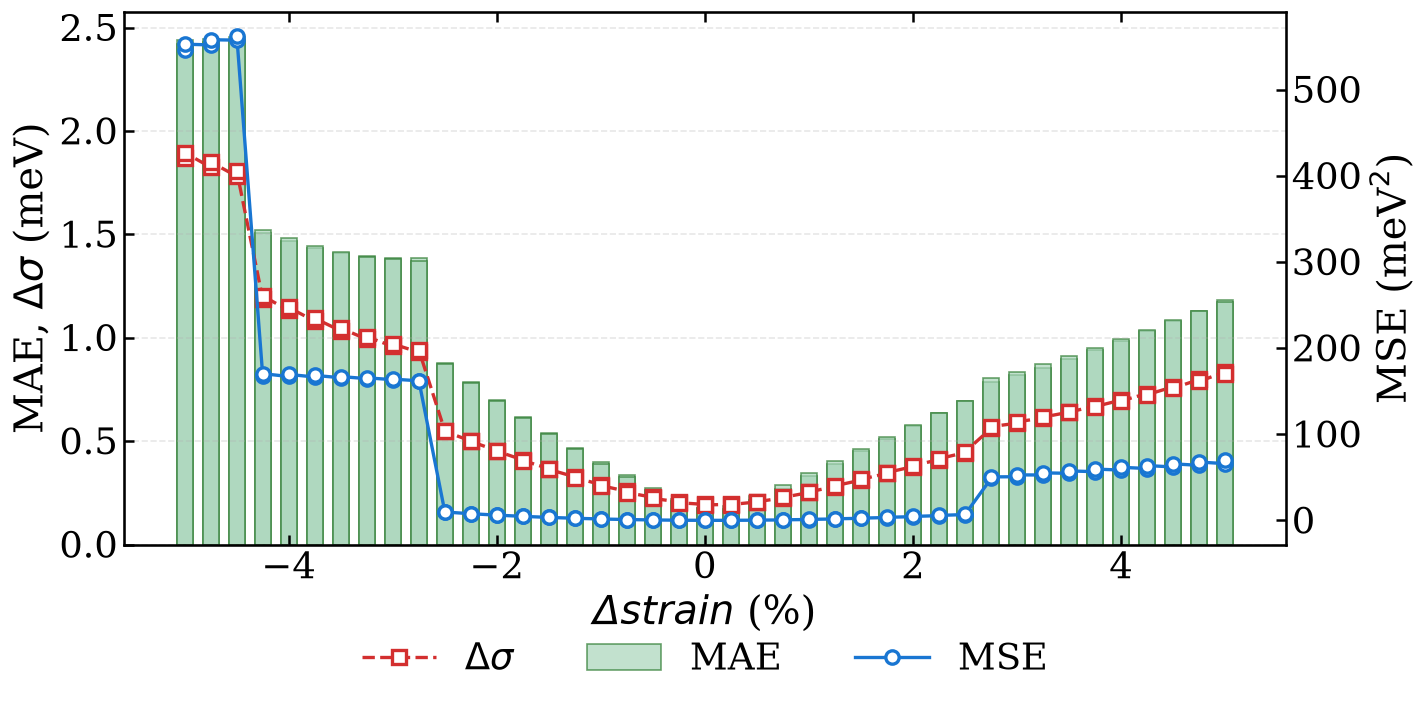

In [4]:
plot_paths=[]
summary=[]
for material in ('bilayer','twisted'):
    for task,delta in [('bond','Delta_cc'),('d','Delta_vdw'),('strain','Delta_strain')]:
        frame=read_archived_table(DOC/'data'/f'{material}_{task}_error_analyze.csv')
        assert len(frame)>2 and frame[delta].nunique()>1
        csv=OUT/f'{material}_{task}_plot_input.csv'
        frame.to_csv(csv,index=False)
        output=OUT/f'{material}_{task}_errors.png'
        plotting.plot_error_analysis(str(csv),str(output),x_delta=delta,figsize=(12,6),dpi=120)
        plot_paths.append(output)
        summary.append({'system':material,'perturbation':task,'structures':len(frame),
                        'Pearson r (MAE, mean STD)':np.corrcoef(frame['MAE'],frame['Avg_STD'])[0,1]})
display(pd.DataFrame(summary))
display(Image(filename=str(plot_paths[2]),width=900))

## Band comparison

Read the DFT-reference and ensemble-mean bands calculated in notebook 02 and save their comparison as a separate figure. The plotting function's `ylim` argument is in eV. This example displays energies within 3 eV of the reference Fermi level. It uses the existing band-alignment and plotting behavior.

Band structure saved to: <repository>\doc\output\bilayer_band_comparison.png
Energy range: [-3.00, 3.00] eV
High symmetry points: ['$\\Gamma$', 'M', 'K', '$\\Gamma$']


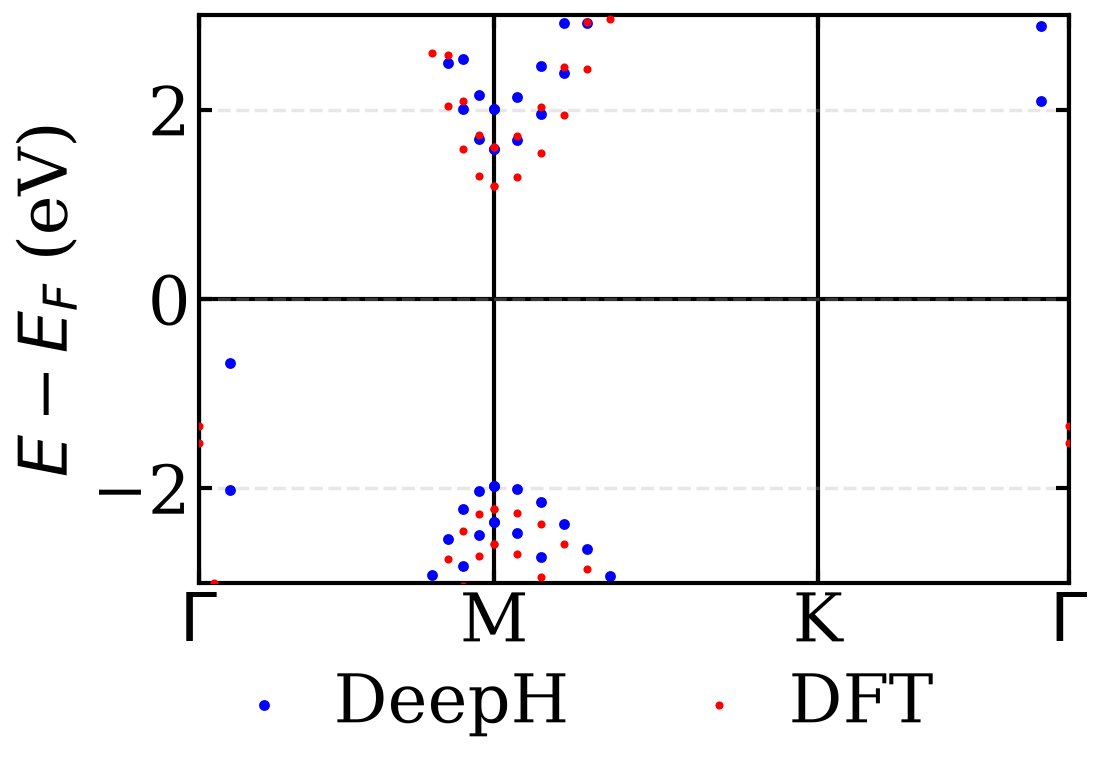

Saved six structural-sweep figures and one band-comparison figure separately in doc/output.


In [5]:
band_directory = OUT/'bands'
assert all((band_directory/f'openmx_{name}.Band').is_file() for name in ('dft','mean')),     'Run notebook 02 to calculate the band files first.'
band_figure = OUT/'bilayer_band_comparison.png'
bands.plot_band_structure(str(band_directory), str(band_figure), ylim=(-3,3),
                          show_ensemble=False, align_method='fermi', figsize=(7,5), dpi=160)
display(Image(filename=str(band_figure), width=700))
print('Saved six structural-sweep figures and one band-comparison figure separately in doc/output.')